## Subpoint (a): Interpolation of Runge's Function

We are tasked with evaluating the numerical stability of three different interpolation methods on two specific mathematical functions:
1. Runge's function: $f_1(x) = \frac{1}{1+25x^2}$ defined on $[-1, 1]$.
2. Exponential-trigonometric function: $f_2(x) = \exp(\cos(x))$ defined on $[0, 2\pi]$.

For Subpoint (a), we will focus on $f_1(x)$ using exactly $N=12$ interpolation nodes. We will utilize `scipy.interpolate.BarycentricInterpolator` for Lagrange polynomials (as it provides superior numerical stability) and `scipy.interpolate.CubicSpline` for spline interpolation. 

To create smooth curves, the polynomial and spline evaluation will be sampled on a grid 10 times denser than the interpolation nodes.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import BarycentricInterpolator, CubicSpline

# 1. Define the mathematical functions
def f1(x):
    return 1 / (1 + 25 * x**2)

def f2(x):
    return np.exp(np.cos(x))

# 2. General functions to generate exactly N nodes in a given interval [a, b]
def generate_uniform(a, b, n):
    return np.linspace(a, b, n)

def generate_chebyshev(a, b, n):
    # Standard Chebyshev nodes in [-1, 1] mapped to [a, b]
    j = np.arange(1, n + 1)
    nodes_standard = np.cos((2 * j - 1) / (2 * n) * np.pi)
    # Map from [-1, 1] to [a, b] and sort them for spline compatibility
    return np.sort(0.5 * (b - a) * nodes_standard + 0.5 * (a + b))

Now, we apply the 12 nodes to $f_1(x)$. We will construct three distinct interpolators:
* **Lagrange with Uniform Nodes:** Expected to suffer heavily from Runge's phenomenon near the edges.
* **Cubic Spline with Uniform Nodes:** Expected to remain stable as it acts locally (piecewise polynomials).
* **Lagrange with Chebyshev Nodes:** Expected to remain stable globally due to the denser clustering of nodes at the interval boundaries.

For plotting, we generate a 10x denser set. For Chebyshev nodes, we sample uniformly in $\theta \in [0, \pi]$ and project using $x = \cos(\theta)$, matching the instruction.

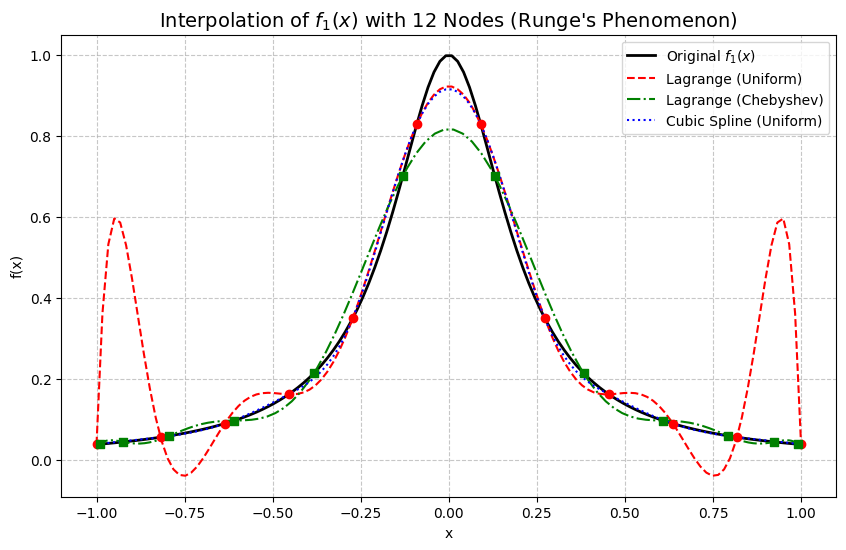

In [3]:
n_nodes = 12
a, b = -1, 1

# 1. Generate the 12 interpolation nodes
x_uni = generate_uniform(a, b, n_nodes)
x_cheb = generate_chebyshev(a, b, n_nodes)

# 2. Create 10x denser sampling sets for smooth plotting
x_dense_uni = np.linspace(a, b, n_nodes * 10)
theta_dense = np.linspace(0, np.pi, n_nodes * 10)
x_dense_cheb = np.sort(np.cos(theta_dense))

# 3. Fit the interpolators
lagrange_uni = BarycentricInterpolator(x_uni, f1(x_uni))
lagrange_cheb = BarycentricInterpolator(x_cheb, f1(x_cheb))
spline_uni = CubicSpline(x_uni, f1(x_uni))

# 4. Visualization
plt.figure(figsize=(10, 6))

# Original function
plt.plot(x_dense_uni, f1(x_dense_uni), 'k-', linewidth=2, label='Original $f_1(x)$')

# Interpolations
plt.plot(x_dense_uni, lagrange_uni(x_dense_uni), 'r--', label="Lagrange (Uniform)")
plt.plot(x_dense_cheb, lagrange_cheb(x_dense_cheb), 'g-.', label="Lagrange (Chebyshev)")
plt.plot(x_dense_uni, spline_uni(x_dense_uni), 'b:', label="Cubic Spline (Uniform)")

# Overlay the actual interpolation nodes (data points)
plt.scatter(x_uni, f1(x_uni), color='red', marker='o', zorder=5)
plt.scatter(x_cheb, f1(x_cheb), color='green', marker='s', zorder=5)

plt.title("Interpolation of $f_1(x)$ with 12 Nodes (Runge's Phenomenon)", fontsize=14)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Subpoint (b): Error Norm Analysis ($n = 4 \dots 50$)

Visual observation is insufficient for rigorous numerical analysis. We will now quantify the error of these three methods for both $f_1(x)$ and $f_2(x)$ as the number of nodes $N$ increases from 4 to 50.

We evaluate the models on a validation set of 500 randomly distributed points within the respective domains. The performance metric is the **$L_2$ norm of the error vector** (the Euclidean length of the differences between true values and predicted values). 

*(Note: We use a logarithmic scale for the y-axis, as the errors for Lagrange with uniform nodes grow exponentially due to the Runge phenomenon).*

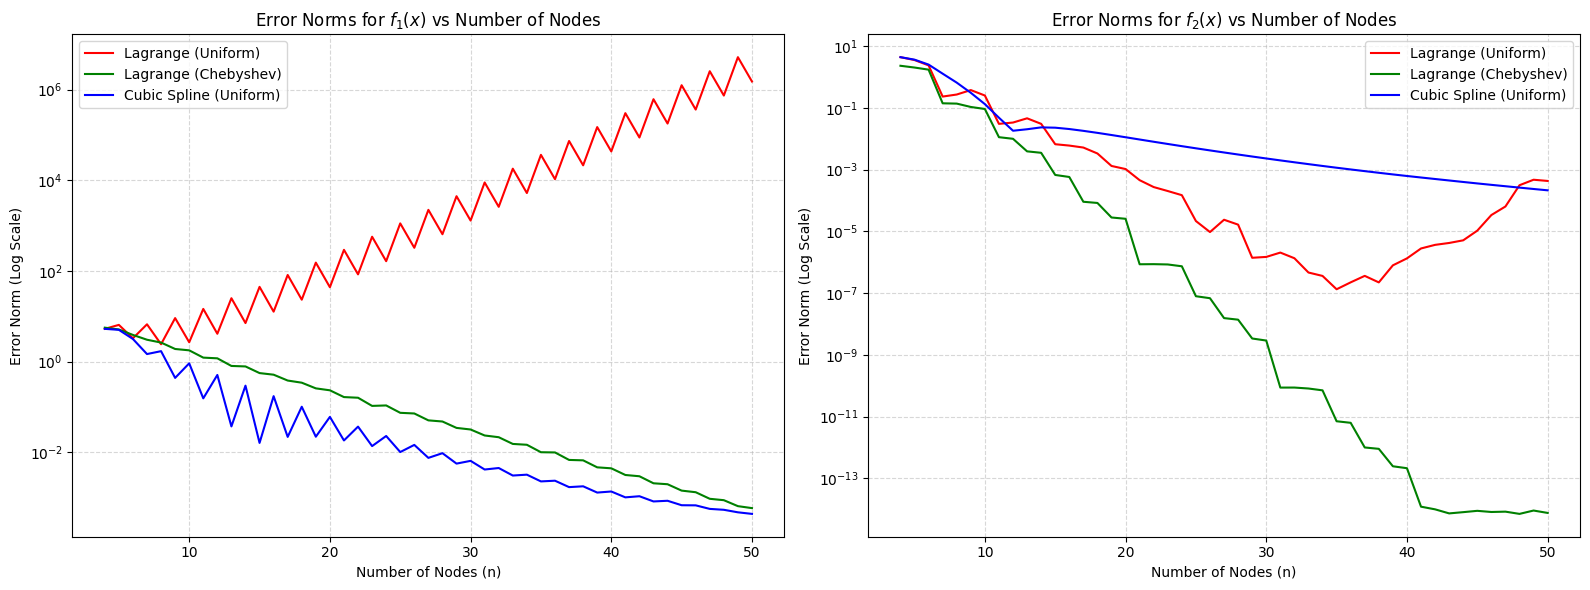

In [8]:
# 1. Setup validation parameters
n_range = range(4, 51)
np.random.seed(42) # For reproducibility

# 500 random points for each domain
pts_f1 = np.random.uniform(-1, 1, 500)
pts_f2 = np.random.uniform(0, 2*np.pi, 500)

# Arrays to store error norms
errors_f1 = {'Lagrange_Uni': [], 'Lagrange_Cheb': [], 'Spline_Uni': []}
errors_f2 = {'Lagrange_Uni': [], 'Lagrange_Cheb': [], 'Spline_Uni': []}

# 2. Iterate through n nodes
for n in n_range:
    # Nodes for f1
    x_uni_f1 = generate_uniform(-1, 1, n)
    x_cheb_f1 = generate_chebyshev(-1, 1, n)
    
    # Nodes for f2
    x_uni_f2 = generate_uniform(0, 2*np.pi, n)
    x_cheb_f2 = generate_chebyshev(0, 2*np.pi, n) 
    
    # Compute and store errors for f1
    lag_u_f1 = BarycentricInterpolator(x_uni_f1, f1(x_uni_f1))(pts_f1)
    lag_c_f1 = BarycentricInterpolator(x_cheb_f1, f1(x_cheb_f1))(pts_f1)
    spl_u_f1 = CubicSpline(x_uni_f1, f1(x_uni_f1))(pts_f1)
    
    errors_f1['Lagrange_Uni'].append(np.linalg.norm(lag_u_f1 - f1(pts_f1)))
    errors_f1['Lagrange_Cheb'].append(np.linalg.norm(lag_c_f1 - f1(pts_f1))) # OCZYSZCZONE z "if False"
    errors_f1['Spline_Uni'].append(np.linalg.norm(spl_u_f1 - f1(pts_f1)))

    # Compute and store errors for f2
    lag_u_f2 = BarycentricInterpolator(x_uni_f2, f2(x_uni_f2))(pts_f2)
    lag_c_f2 = BarycentricInterpolator(x_cheb_f2, f2(x_cheb_f2))(pts_f2)
    spl_u_f2 = CubicSpline(x_uni_f2, f2(x_uni_f2))(pts_f2)
    
    errors_f2['Lagrange_Uni'].append(np.linalg.norm(lag_u_f2 - f2(pts_f2)))
    errors_f2['Lagrange_Cheb'].append(np.linalg.norm(lag_c_f2 - f2(pts_f2)))
    errors_f2['Spline_Uni'].append(np.linalg.norm(spl_u_f2 - f2(pts_f2)))

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot f1 errors
ax1.plot(n_range, errors_f1['Lagrange_Uni'], 'r-', label='Lagrange (Uniform)')
ax1.plot(n_range, errors_f1['Lagrange_Cheb'], 'g-', label='Lagrange (Chebyshev)')
ax1.plot(n_range, errors_f1['Spline_Uni'], 'b-', label='Cubic Spline (Uniform)')
ax1.set_yscale('log')
ax1.set_title("Error Norms for $f_1(x)$ vs Number of Nodes")
ax1.set_xlabel("Number of Nodes (n)")
ax1.set_ylabel("Error Norm (Log Scale)")
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# Plot f2 errors
ax2.plot(n_range, errors_f2['Lagrange_Uni'], 'r-', label='Lagrange (Uniform)')
ax2.plot(n_range, errors_f2['Lagrange_Cheb'], 'g-', label='Lagrange (Chebyshev)')
ax2.plot(n_range, errors_f2['Spline_Uni'], 'b-', label='Cubic Spline (Uniform)')
ax2.set_yscale('log')
ax2.set_title("Error Norms for $f_2(x)$ vs Number of Nodes")
ax2.set_xlabel("Number of Nodes (n)")
ax2.set_ylabel("Error Norm (Log Scale)")
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()